<a href="https://colab.research.google.com/github/anigan27/Brain-Tumor-Classification/blob/main/github_cleanlab_find_mislabeled_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from os import mkdir
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from numpy import expand_dims


In [ ]:
!pip install matplotlib torch torchvision skorch
!pip install cleanlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.4/239.4 kB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.3/63.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.6/353.6 kB 28.6 MB/s eta 0:00:00


In [ ]:
#loading dataset to colab
# the link with how to load the dataset from kaggle to colab
#https://www.geeksforgeeks.org/how-to-import-kaggle-datasets-directly-into-google-colab/
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri
!unzip brain-tumor-classification-mri

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
100% 86.8M/86.8M [00:05<00:00, 21.1MB/s]
100% 86.8M/86.8M [00:05<00:00, 16.8MB/s]
Archive:  brain-tumor-classification-mri.zip
  inflating: Testing/glioma_tumor/image(1).jpg  
  inflating: Testing/glioma_tumor/image(10).jpg  
  inflating: Testing/glioma_tumor/image(100).jpg  
  inflating: Testing/glioma_tumor/image(11).jpg  
  inflating: Testing/glioma_tumor/image(12).jpg  
  inflating: Testing/glioma_tumor/image(13).jpg  
  inflating: Testing/glioma_tumor/image(14).jpg  
  inflating: Testing/glioma_tumor/image(15).jpg  
  inflating: Testing/glioma_tumor/image(16).jpg  
  inflating: Testing/glioma_tumor/image(17).jpg  
  inflating: Testing/glioma_tumor/image(18).jpg  
  inflating: Testing/glioma_tumor/image(19).jpg  
  inflating: Testing/glioma_tumor/

In [ ]:
train_directory = '/content/Training'
test_directory = '/content/Testing'
categories = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
image_size = 224

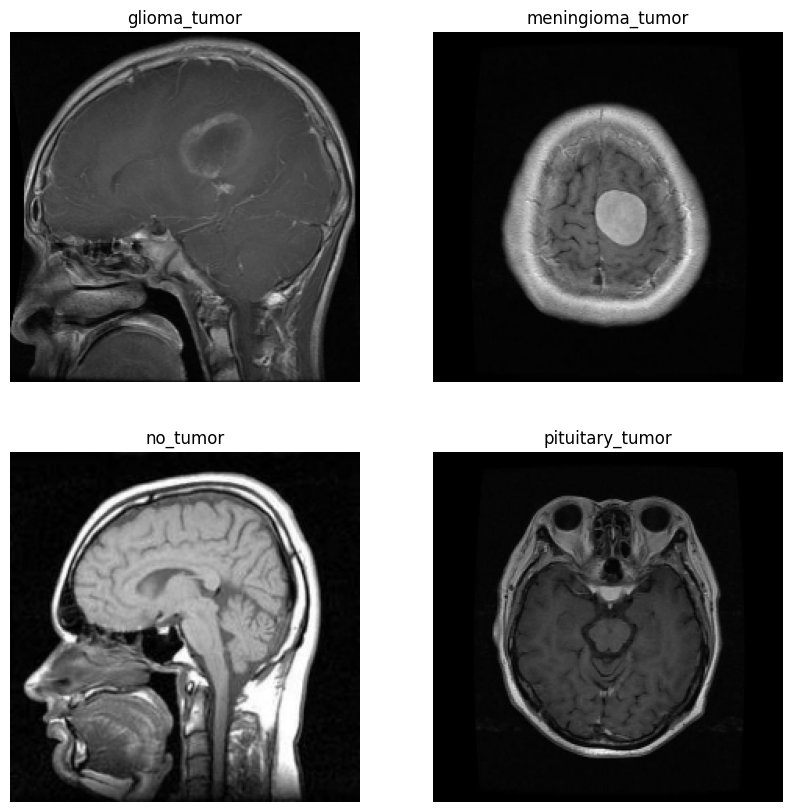

In [ ]:
import os
tumor_data = []
tumor_labels = []
#dictionary of image name
image_paths = []

plt.figure(figsize=(10, 10))
for label in range(len(categories)):
    class_name = categories[label]
    class_path = os.path.join(train_directory, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image = cv2.imread(image_path)
        image_paths.append(image_path)
        if image is not None:
            #Resize image
            image_resized = cv2.resize(image, (image_size, image_size))
            #Normalize image
            image_resized = image_resized / 255.0
            tumor_data.append(image_resized)
            tumor_labels.append(label)
    plt.subplot(2, 2, label + 1)
    plt.axis('off')
    plt.title(class_name)
    plt.imshow(image_resized)
plt.show()


X_train = np.array(tumor_data)

y_train = np.array(tumor_labels)



In [ ]:
y_train.shape

(2870,)

In [ ]:
y_train[9]

0

In [ ]:

X_train.shape

(2870, 224, 224, 3)

In [ ]:
print(image_paths[1234])

/content/Training/meningioma_tumor/m3 (210).jpg


In [ ]:
#Reshape X_train
X_train = X_train.astype('float32')
X_train = X_train.reshape(X_train.shape[0], 3, image_size, image_size)
X_train.shape

(2870, 3, 224, 224)

In [ ]:
from torch import nn


class ClassifierModule(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(6),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(kernel_size=2, stride=2),

        )
        self.out = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(128),
            nn.ReLU(),
            nn.Linear(128, 4),  # Adjust the input size of the linear layer
            nn.Softmax(dim=-1),
        )

    def forward(self, X):
        X = self.cnn(X)
        X = self.out(X)
        return X

In [ ]:
from skorch import NeuralNetClassifier

model_skorch = NeuralNetClassifier(ClassifierModule, max_epochs=10)

In [ ]:
from sklearn.model_selection import cross_val_predict

num_crossval_folds = 5
pred_probs = cross_val_predict(model_skorch, X_train, y_train,
                               cv=num_crossval_folds,
                               method='predict_proba')

  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        1.8066       0.2870        3.0199  12.2809
      2        1.5514       0.2457        3.4104  12.4344
      3        1.4039       0.3891        2.6102  13.3280
      4        1.3203       0.3674        1.6726  12.7262
      5        1.0976       0.3500        1.4716  12.2897
      6        0.9719       0.3826        1.4179  12.0801
      7        0.9378       0.4283        1.3355  12.1202
      8        0.8905       0.4587        1.2953  12.0746
      9        0.8212       0.4630        1.2745  12.0988
     10        0.7386       0.4848        1.2385  12.1337
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        1.8158       0.2696        1.6234  12.2844
      2        1.3870       0.3630        1.6296  12.3223
      3        1.0920       0.4065        1.4512  12.1443
      4       

In [ ]:
from sklearn.metrics import accuracy_score

predicted_labels = pred_probs.argmax(axis=1)
acc = accuracy_score(y_train, predicted_labels)

print(f"Cross-validated estimate of accuracy on held-out data: {acc}")

Cross-validated estimate of accuracy on held-out data: 0.5477351916376306


In [ ]:
from cleanlab.filter import find_label_issues

ranked_label_issues = find_label_issues(y_train, pred_probs, return_indices_ranked_by="self_confidence")

print(f"Cleanlab found {len(ranked_label_issues)} label issues.")
print("Here are the indices of the top 50 most likely label errors:\n"
      f"{ranked_label_issues[:50]}")



/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Cleanlab found 806 label issues.
Here are the indices of the top 50 most likely label errors:
[1101 1048 1078 1810 1233 1701 1038 1050 1884 1134  321   58 1308 1084
 1505  920 1593 1319 1073 1423  261 1001 1414 1900 2023  199  979 1845
 2001  142 1484  825 1839 1228 1302  690  785 1226  438 1862   66  317
   40 1367 1346 1113  285  458  472    6]
/content/Training/meningioma_tumor/m3 (139).jpg
/content/Training/meningioma_tumor/m1(139).jpg
/content/Training/meningioma_tumor/m1(166).jpg
/content/Training/no_tumor/image (54).jpg
/content/Training/meningioma_tumor/m1(6).jpg
/content/Training/no_tumor/image(178).jpg
/content/Training/meningioma_tumor/m3 (135).jpg
/content/Training/meningioma_tumor/m2 (132).jpg
/content/Training/no_tumor/image(27).jpg
/content/Training/meningioma_tumor/m1(179).jpg
/content/Training/glioma_tumor/gg (114).jpg
/content/Training/glioma_tumor/gg (232).jpg
/content/Training/meningioma_tumor/m1(5).jpg
/content/Training/meningioma_tumor/m3 (141).jpg
/content/Traini

In [ ]:


def print_label_summary(tumor_type):
   num_bad_labels = 0
   num_labels = 0
   for i in ranked_label_issues:

      if tumor_type in image_paths[i]:
         print(image_paths[i])
         num_bad_labels +=1

   for i in image_paths:
      if tumor_type in i:
         num_labels +=1

   print(f"{tumor_type}: {num_bad_labels}/{num_labels}")


In [ ]:
for category in categories:
  print_label_summary(category)


glioma_tumor: 479/826
meningioma_tumor: 225/822
no_tumor: 69/395
pituitary_tumor: 33/827


In [ ]:
print_label_summary('glioma_tumor')

/content/Training/glioma_tumor/gg (114).jpg
/content/Training/glioma_tumor/gg (232).jpg
/content/Training/glioma_tumor/gg (113).jpg
/content/Training/glioma_tumor/gg (230).jpg
/content/Training/glioma_tumor/gg (338).jpg
/content/Training/glioma_tumor/gg (112).jpg
/content/Training/glioma_tumor/gg (149).jpg
/content/Training/glioma_tumor/gg (142).jpg
/content/Training/glioma_tumor/gg (158).jpg
/content/Training/glioma_tumor/gg (103).jpg
/content/Training/glioma_tumor/gg (89).jpg
/content/Training/glioma_tumor/gg (212).jpg
/content/Training/glioma_tumor/gg (121).jpg
/content/Training/glioma_tumor/gg (698).jpg
/content/Training/glioma_tumor/gg (432).jpg
/content/Training/glioma_tumor/gg (225).jpg
/content/Training/glioma_tumor/gg (67).jpg
/content/Training/glioma_tumor/gg (553).jpg
/content/Training/glioma_tumor/gg (85).jpg
/content/Training/glioma_tumor/gg (422).jpg
/content/Training/glioma_tumor/gg (65).jpg
/content/Training/glioma_tumor/gg (651).jpg
/content/Training/glioma_tumor/gg (5

# Redo the same with testing directory to find how many bad labels of each category

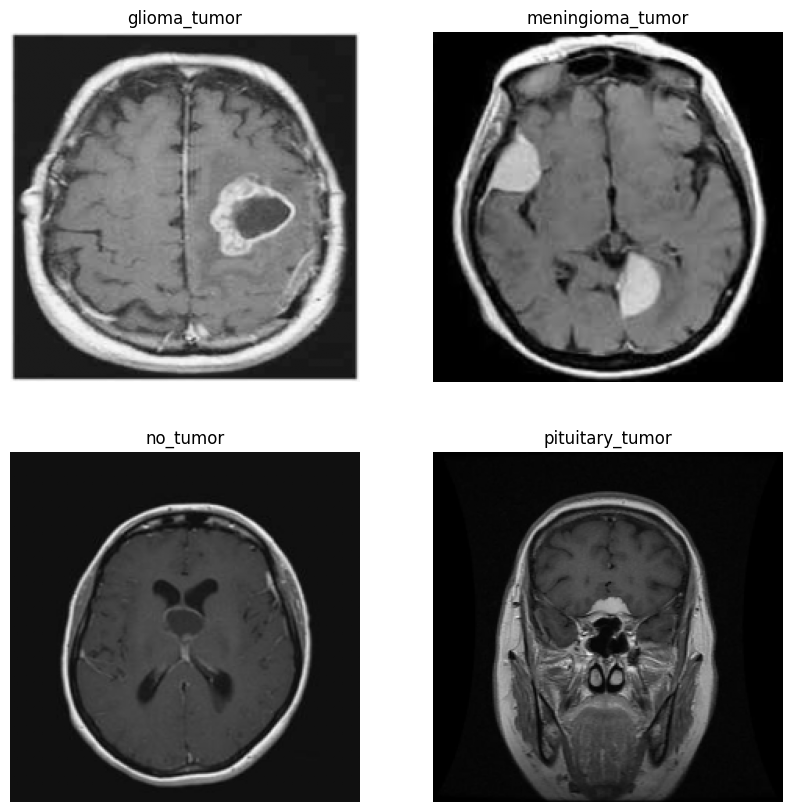

In [ ]:
import os
tumor_test_data = []
tumor_test_labels = []
#dictionary of image name
test_image_paths = []

plt.figure(figsize=(10, 10))
for label in range(len(categories)):
    class_name = categories[label]
    class_path = os.path.join(test_directory, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image = cv2.imread(image_path)
        test_image_paths.append(image_path)
        if image is not None:
            #Resize image
            image_resized = cv2.resize(image, (image_size, image_size))
            #Normalize image
            image_resized = image_resized / 255.0
            tumor_test_data.append(image_resized)
            tumor_test_labels.append(label)
    plt.subplot(2, 2, label + 1)
    plt.axis('off')
    plt.title(class_name)
    plt.imshow(image_resized)
plt.show()


X_train = np.array(tumor_test_data)

y_train = np.array(tumor_test_labels)



In [ ]:
#Reshape X_train
X_train = X_train.astype('float32')
X_train = X_train.reshape(X_train.shape[0], 3, image_size, image_size)
X_train.shape

(394, 3, 224, 224)

In [ ]:
from sklearn.model_selection import cross_val_predict

num_crossval_folds = 5
pred_probs = cross_val_predict(model_skorch, X_train, y_train,
                               cv=num_crossval_folds,
                               method='predict_proba')

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        3.6308       0.4127        1.3820  1.8838
      2        1.3477       0.2222        1.3972  1.6260
      3        1.1446       0.2540        1.4313  1.5795
      4        0.9806       0.2857        1.4868  1.6175
      5        0.8376       0.3016        1.5677  1.5848
      6        0.7265       0.3016        1.6630  1.6360
      7        0.6353       0.3016        1.7469  1.8535
      8        0.5343       0.3016        1.8415  1.9304
      9        0.4755       0.2857        1.8844  1.5858
     10        0.3987       0.2698        1.9301  1.6357
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        3.8996       0.3333        1.3770  1.6605
      2        1.6355       0.1905        1.3753  1.6519
      3        1.2293       0.2698        1.4062  1.6186
      4        1.0783       0.2

In [ ]:
from sklearn.metrics import accuracy_score

predicted_labels = pred_probs.argmax(axis=1)
acc = accuracy_score(y_train, predicted_labels)

print(f"Cross-validated estimate of accuracy on held-out data: {acc}")

Cross-validated estimate of accuracy on held-out data: 0.2817258883248731


In [ ]:
from cleanlab.filter import find_label_issues

ranked_label_issues = find_label_issues(y_train, pred_probs, return_indices_ranked_by="self_confidence")

print(f"Cleanlab found {len(ranked_label_issues)} label issues.")
print("Here are the indices of the top 50 most likely label errors:\n"
      f"{ranked_label_issues[:50]}")



/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Cleanlab found 220 label issues.
Here are the indices of the top 50 most likely label errors:
[331 324 328 327 326 225 330 332 322 230 232 329 129 224 221 235 220 139
 123 234 136 216 217 124 222 145 127 228 134 141 138 231 208 321 133 132
 125 142 131 135 226 227 195 140 202 144 196 187 192  93]


In [ ]:


def print_test_label_summary(tumor_type):
   num_bad_labels = 0
   num_labels = 0
   for i in ranked_label_issues:

      if tumor_type in test_image_paths[i]:
         print(test_image_paths[i])
         num_bad_labels +=1

   for i in test_image_paths:
      if tumor_type in i:
         num_labels +=1

   print(f"{tumor_type}: {num_bad_labels}/{num_labels}")


In [ ]:
for category in categories:
  print_test_label_summary(category)


/content/Testing/glioma_tumor/image(39).jpg
/content/Testing/glioma_tumor/image(67).jpg
/content/Testing/glioma_tumor/image(64).jpg
/content/Testing/glioma_tumor/image(88).jpg
/content/Testing/glioma_tumor/image(32).jpg
/content/Testing/glioma_tumor/image(34).jpg
/content/Testing/glioma_tumor/image(66).jpg
/content/Testing/glioma_tumor/image(73).jpg
/content/Testing/glioma_tumor/image(44).jpg
/content/Testing/glioma_tumor/image(47).jpg
/content/Testing/glioma_tumor/image(6).jpg
/content/Testing/glioma_tumor/image(100).jpg
/content/Testing/glioma_tumor/image(17).jpg
/content/Testing/glioma_tumor/image(55).jpg
/content/Testing/glioma_tumor/image(45).jpg
/content/Testing/glioma_tumor/image(61).jpg
/content/Testing/glioma_tumor/image(68).jpg
/content/Testing/glioma_tumor/image(27).jpg
/content/Testing/glioma_tumor/image(13).jpg
/content/Testing/glioma_tumor/image(14).jpg
/content/Testing/glioma_tumor/image(54).jpg
/content/Testing/glioma_tumor/image(49).jpg
/content/Testing/glioma_tumor/im